In [ ]:
from google.colab import drive

In [ ]:
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import random, re
import time

# used to supress display of warnings
import warnings

import missingno as mno

# nlp libraries
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from tqdm import tqdm
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
from sklearn.feature_extraction.text import TfidfVectorizer

import holoviews as hv
from holoviews import opts

import os;
from os import makedirs

# sampling methods
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

# import zscore for scaling the data
from scipy.stats import zscore

from scipy.stats import randint as sp_randint

# save models
import pickle

# pre-processing methods
from sklearn.model_selection import train_test_split

# the classification models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# ensemble models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# methods and classes for evaluation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score, roc_auc_score

# cross-validation methods
from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# feature selection methods
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV

# pre-processing methods
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder

# Deep learning libraries
from keras.utils import np_utils

from keras.layers import Input
from keras.layers.merge import Concatenate

from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from keras.models import Model
from tensorflow.keras.layers import Flatten, Activation, Dense, LSTM, BatchNormalization, Embedding, Dropout, Flatten, Bidirectional, GlobalMaxPool1D
from keras.models import model_from_json
from keras.regularizers import l1, l2, l1_l2
from keras.constraints import maxnorm, min_max_norm
from keras.constraints import unit_norm
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.models import model_from_json

from keras.models import load_model
from keras.wrappers.scikit_learn import KerasClassifier

# Keras pre-processing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


/usr/local/lib/python3.7/dist-packages/sklearn/externals/six.py:31: FutureWarning: The module is deprecated in version 0.21 and will be removed in version 0.23 since we've dropped support for Python 2.7. Please rely on the official version of six (https://pypi.org/project/six/).
  "(https://pypi.org/project/six/).", FutureWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.neighbors.base module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.neighbors. Anything that cannot be imported from sklearn.neighbors is now part of the private API.
  warnings.warn(message, FutureWarning)


#Step-1: importing data

In [ ]:

pd.set_option('display.max_columns', None)
df= pd.read_csv("/content/gdrive/MyDrive/AIML/CAPSTONE/Data Set - industrial_safety_and_health_database_with_accidents_description.csv")

In [ ]:
df.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
0,0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...
1,1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...
2,2,2016-01-06 00:00:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...
3,3,2016-01-08 00:00:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...
4,4,2016-01-10 00:00:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'Data', 'Countries', 'Local', 'Industry Sector',
       'Accident Level', 'Potential Accident Level', 'Genre',
       'Employee or Third Party', 'Critical Risk', 'Description'],
      dtype='object')


In [ ]:
df.shape

(425, 11)

In [ ]:
#From the above output,we can see that there are 425 rows and 11 coumns in the dataset.

In [ ]:
# Checking data type of each attribute
#df.dtypes

In [ ]:
# All columns datatype are object except 'Unnamed: 0 ' column.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                425 non-null    int64 
 1   Data                      425 non-null    object
 2   Countries                 425 non-null    object
 3   Local                     425 non-null    object
 4   Industry Sector           425 non-null    object
 5   Accident Level            425 non-null    object
 6   Potential Accident Level  425 non-null    object
 7   Genre                     425 non-null    object
 8   Employee or Third Party   425 non-null    object
 9   Critical Risk             425 non-null    object
 10  Description               425 non-null    object
dtypes: int64(1), object(10)
memory usage: 36.6+ KB


In [ ]:
df.describe(include=['object'])

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
count,425,425,425,425,425,425,425,425,425,425
unique,287,3,12,3,5,6,2,3,33,411
top,2017-02-08 00:00:00,Country_01,Local_03,Mining,I,IV,Male,Third Party,Others,On 02/03/17 during the soil sampling in the re...
freq,6,251,90,241,316,143,403,189,232,3


#From all the above outputs, we have noticed that -
*There are about 425 rows and 11 columns in the dataset.

*Except a 'data' column all other columns are categorical columns.

*Categorical columns - 'Countries', 'Local', 'Industry Sector', 'Accident Level', 'Potential Accident Level', 'Genre', 'Employee or Third Party', 'Critical Risk', 'Description'.


*'Unnamed: 0 ' column we need to remove as it is unnecessary column.

*Country_01 is the country where most of the accidents happened.

*Local_03 (which also belongs to Country_01) is where most of the accidents happened.

*Mining is also the most significant contributor to accidents.

*Male and Third Party also counts for kind of people that suffers more accident.


#Step-2: Data cleansing


In [ ]:
# Remove 'Unnamed: 0 'column
df.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
#df.head()

In [ ]:
# Checking duplicates
df.duplicated().sum()

7

In [ ]:
# View the duplicate records
duplicates = df.duplicated()

df[duplicates]

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
77,2016-04-01 00:00:00,Country_01,Local_01,Mining,I,V,Male,Third Party (Remote),Others,In circumstances that two workers of the Abrat...
262,2016-12-01 00:00:00,Country_01,Local_03,Mining,I,IV,Male,Employee,Others,During the activity of chuteo of ore in hopper...
303,2017-01-21 00:00:00,Country_02,Local_02,Mining,I,I,Male,Third Party (Remote),Others,Employees engaged in the removal of material f...
345,2017-03-02 00:00:00,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
346,2017-03-02 00:00:00,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
355,2017-03-15 00:00:00,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,Team of the VMS Project performed soil collect...
397,2017-05-23 00:00:00,Country_01,Local_04,Mining,I,IV,Male,Third Party,Projection of fragments,In moments when the 02 collaborators carried o...


In [ ]:
df[df['Data'] == '2017-03-02 00:00:00']

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
344,2017-03-02 00:00:00,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
345,2017-03-02 00:00:00,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
346,2017-03-02 00:00:00,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...


In [ ]:
# Removing duplicate rows
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(418, 10)

In [ ]:
df.rename(columns={"Data": "Date"}, inplace=True)

In [ ]:
df.head(2)

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...
1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...


In [ ]:
df.size

4180

**After removing duplicates there are 418 rows and 10 coulmns in the dataset.
There are no missing values in the dataset**

#Step-3: Data preprocessing

*   initialize the data preprocessing step as shared by dipanshu in session-1
*   test each one of those steps

*   put all the steps in a udf
*   Run/apply the udf on pandas df coulmn(description)

*   convert every categorical varriable to numeric dummy varriable













In [ ]:
df.columns

Index(['Date', 'Countries', 'Local', 'Industry Sector', 'Accident Level',
       'Potential Accident Level', 'Genre', 'Employee or Third Party',
       'Critical Risk', 'Description'],
      dtype='object')

In [ ]:
# Check unique values of all columns except 'Description' column
for x in df.columns:
    if x != 'Description':
      print('--'*30); print(f'Unique values of "{x}" column'); print('--'*30)
      print(df[x].unique())
      print('\n')

------------------------------------------------------------
Unique values of "Date" column
------------------------------------------------------------
['2016-01-01 00:00:00' '2016-01-02 00:00:00' '2016-01-06 00:00:00'
 '2016-01-08 00:00:00' '2016-01-10 00:00:00' '2016-01-12 00:00:00'
 '2016-01-16 00:00:00' '2016-01-17 00:00:00' '2016-01-19 00:00:00'
 '2016-01-26 00:00:00' '2016-01-28 00:00:00' '2016-01-30 00:00:00'
 '2016-02-01 00:00:00' '2016-02-02 00:00:00' '2016-02-04 00:00:00'
 '2016-02-06 00:00:00' '2016-02-07 00:00:00' '2016-02-08 00:00:00'
 '2016-02-21 00:00:00' '2016-02-25 00:00:00' '2016-02-09 00:00:00'
 '2016-02-10 00:00:00' '2016-02-15 00:00:00' '2016-02-14 00:00:00'
 '2016-02-13 00:00:00' '2016-02-16 00:00:00' '2016-02-17 00:00:00'
 '2016-02-19 00:00:00' '2016-02-20 00:00:00' '2016-02-18 00:00:00'
 '2016-02-22 00:00:00' '2016-02-24 00:00:00' '2016-02-29 00:00:00'
 '2016-02-26 00:00:00' '2016-02-27 00:00:00' '2016-03-02 00:00:00'
 '2016-03-03 00:00:00' '2016-03-04 00:00:00

In [ ]:
df['Countries'].value_counts()

Country_01    248
Country_02    129
Country_03     41
Name: Countries, dtype: int64

We observed that there are records of accidents from 1st Jan 2016 to 9th July 2017 in every month. So there are no outliers in the 'Date' column.

There are only three country types so there are no outliers in 'Country' column.

There are 12 Local cities where manufacturing plant is located and it's types are in sequence so there are no outliers in 'Local' column.

There are only three Industry Sector types which are in sequence so there are no outliers in 'Industry Sector' column.

There are only five Accident Level types which are in sequence so there are no outliers in 'Accident Level' column.

There are only six Potential Accident Level types which are in sequence so there are no outliers in 'Potential Accident Level' column.

There are only two Gender types in the provided data so there are no outliers in 'Genre' column.

There are quite a lot of Critical risk descriptions and we don't see any outliers.

In [ ]:
dd = df['Description'][df['Countries'] == 'Country_03'].to_numpy(dtype=object)


In [ ]:
dd[0]

'When accessing the Santa do Novo area, in order to open the chop, General was moving ahead of the team in order to open access for Manetometer, when he came across an area with a steep slope and gravel presence. In a certain place of access the employee slipped, coming with this to become unbalanced. At that moment the machete that was in his left hand came to slip the right leg above the knee, causing a cut 3cm.'

In [ ]:
#To better understand the data, let's extracting the day, month and year from Date column and creating new features such as weekday, weekofyear.
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df.Date.apply(lambda x : x.year)
df['Month'] = df.Date.apply(lambda x : x.month)
df['Day'] = df.Date.apply(lambda x : x.day)
df['Weekday'] = df.Date.apply(lambda x : x.day_name())
df['WeekofYear'] = df.Date.apply(lambda x : x.weekofyear)

df.head()

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,53
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,53
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,1
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,2016,1,8,Friday,1
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,2016,1,10,Sunday,1


As we know, this database comes from one of the biggest industry in Brazil which has four climatological seasos as below.

https://seasonsyear.com/Brazil

Spring : September to November
Summer : December to February
Autumn : March to May
Winter : June to August
We can create seasonal variable based on month variable.


In [ ]:
# function to create month variable into seasons
def month2seasons(x):
    if x in [9, 10, 11]:
        season = 'Spring'
    elif x in [12, 1, 2]:
        season = 'Summer'
    elif x in [3, 4, 5]:
        season = 'Autumn'
    elif x in [6, 7, 8]:
        season = 'Winter'
    return season

In [ ]:
df['Season'] = df['Month'].apply(month2seasons)
df.head(3)

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear,Season
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,53,Summer
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,53,Summer
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,1,Summer


We can create holidays variable based on Brazil holidays list from 2016 and 2017.

Another national holidays are election days. There are a plenty of unofficial ethnic and religious holidays in Brazil. Octoberfest, Brazilian Carnival, Kinderfest, Fenaostra, Fenachopp, Musikfest, Schutzenfest, Kegelfest, Cavalhadas, Oberlandfest, Tirolerfest, Marejada are among them.

Note: Considering official holidays only.

In [ ]:
import holidays

brazil_holidays = []

print('--'*40); print('List of Brazil holidays in 2016'); print('--'*40)
for date in holidays.Brazil(years = 2016).items():
    brazil_holidays.append(str(date[0]))
    print(date)

print('--'*40); print('List of Brazil holidays in 2017'); print('--'*40)
for date in holidays.Brazil(years = 2017).items():
    brazil_holidays.append(str(date[0]))
    print(date)

--------------------------------------------------------------------------------
List of Brazil holidays in 2016
--------------------------------------------------------------------------------
(datetime.date(2016, 1, 1), 'Ano novo')
(datetime.date(2016, 4, 21), 'Tiradentes')
(datetime.date(2016, 5, 1), 'Dia Mundial do Trabalho')
(datetime.date(2016, 9, 7), 'Independência do Brasil')
(datetime.date(2016, 10, 12), 'Nossa Senhora Aparecida')
(datetime.date(2016, 11, 2), 'Finados')
(datetime.date(2016, 11, 15), 'Proclamação da República')
(datetime.date(2016, 12, 25), 'Natal')
(datetime.date(2016, 3, 25), 'Sexta-feira Santa')
(datetime.date(2016, 3, 27), 'Páscoa')
(datetime.date(2016, 5, 26), 'Corpus Christi')
(datetime.date(2016, 2, 10), 'Quarta-feira de cinzas (Início da Quaresma)')
(datetime.date(2016, 2, 9), 'Carnaval')
--------------------------------------------------------------------------------
List of Brazil holidays in 2017
------------------------------------------------------

In [ ]:
df['Is_Holiday'] = [1 if str(val).split()[0] in brazil_holidays else 0 for val in df['Date']]
df.head()

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear,Season,Is_Holiday
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,53,Summer,1
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,53,Summer,0
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,1,Summer,0
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,2016,1,8,Friday,1,Summer,0
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,2016,1,10,Sunday,1,Summer,0



*   Target variable: 'Accident Level', 'Potential Accident Level'
*   Predictors (Input varibles): 'Date', 'Country', 'Local', 'Industry Sector', 'Gender', 'Employee type', 'Critical Risk', 'Description'



**Univariate** **Analysis**

------------------------------------------------------------
Value Counts for `Countries` label
------------------------------------------------------------
Country_01 count: 248 i.e. 59.0%
Country_02 count: 129 i.e. 31.0%
Country_03 count: 41 i.e. 10.0%
------------------------------------------------------------
Distributon of `Countries` label
------------------------------------------------------------


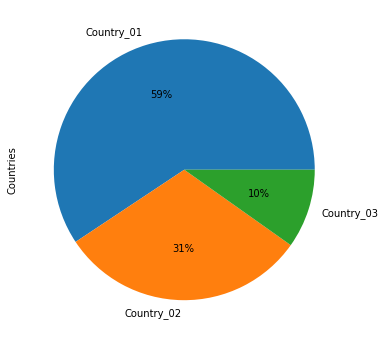

In [ ]:
#country
print('--'*30); print('Value Counts for `Countries` label'); print('--'*30)

total_row_cnt = df.shape[0]
country_01_cnt = df[df.Countries == 'Country_01'].shape[0]
country_02_cnt = df[df.Countries == 'Country_02'].shape[0]
country_03_cnt = df[df.Countries == 'Country_03'].shape[0]

print(f'Country_01 count: {country_01_cnt} i.e. {round(country_01_cnt/total_row_cnt*100, 0)}%')
print(f'Country_02 count: {country_02_cnt} i.e. {round(country_02_cnt/total_row_cnt*100, 0)}%')
print(f'Country_03 count: {country_03_cnt} i.e. {round(country_03_cnt/total_row_cnt*100, 0)}%')

print('--'*30); print('Distributon of `Countries` label'); print('--'*30)
_ = df['Countries'].value_counts().plot(kind = 'pie', autopct = '%.0f%%', labels = ['Country_01', 'Country_02', 'Country_03'], figsize = (10, 6))




*   59% accidents occurred in Country_01
*   31% accidents occurred in Country_02
*   10% accidents occurred in Country_03






In [ ]:
#Local

import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

local_cnt = np.round(df['Local'].value_counts(normalize=True) * 100)

hv.extension('bokeh')
hv.Bars(local_cnt).opts(title="Local Count", color="#8888ff", xlabel="Locals", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=700, height=300,tools=['hover'],show_grid=True))

Output hidden; open in https://colab.research.google.com to view.



*   Highest manufacturing plants are located in Local_03 city.

*   Lowest manufacturing plants are located in Local_09 city.



In [ ]:
#Industry sector

print('--'*30); print('Value Counts for `Industry Sector` label'); print('--'*30)

Mining_cnt = df[df['Industry Sector'] == 'Mining'].shape[0]
Metals_cnt = df[df['Industry Sector'] == 'Metals'].shape[0]
Others_cnt = df[df['Industry Sector'] == 'Others'].shape[0]

print(f'Mining count: {Mining_cnt} i.e. {round(Mining_cnt/total_row_cnt*100, 0)}%')
print(f'Metals count: {Metals_cnt} i.e. {round(Metals_cnt/total_row_cnt*100, 0)}%')
print(f'Others count: {Others_cnt} i.e. {round(Others_cnt/total_row_cnt*100, 0)}%')

print('--'*30); print('Distributon of `Industry Sector` label'); print('--'*30)

sector_cnt = np.round(df['Industry Sector'].value_counts(normalize=True) * 100)

hv.extension('bokeh')

hv.Bars(sector_cnt).opts(title="Industry Sector Count", color="#8888ff", xlabel="Sectors", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=500, height=300,tools=['hover'],show_grid=True))\
                * hv.Text('Mining', 15, f"{int(sector_cnt.loc['Mining'])}%")\
                * hv.Text('Metals', 15, f"{int(sector_cnt.loc['Metals'])}%")\
                * hv.Text('Others', 15, f"{int(sector_cnt.loc['Others'])}%")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Accident Level

print('--'*30); print('Value Counts for `Accident Level` label'); print('--'*40)

I_acc_cnt = df[df['Accident Level'] == 'I'].shape[0]
II_acc_cnt = df[df['Accident Level'] == 'II'].shape[0]
III_acc_cnt = df[df['Accident Level'] == 'III'].shape[0]
IV_acc_cnt = df[df['Accident Level'] == 'IV'].shape[0]
V_acc_cnt = df[df['Accident Level'] == 'V'].shape[0]
VI_acc_cnt = df[df['Accident Level'] == 'VI'].shape[0]

print(f'Accident Level - I count: {I_acc_cnt} i.e. {round(I_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Accident Level - II count: {II_acc_cnt} i.e. {round(II_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Accident Level - III count: {III_acc_cnt} i.e. {round(III_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Accident Level - IV count: {IV_acc_cnt} i.e. {round(IV_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Accident Level - V count: {V_acc_cnt} i.e. {round(V_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Accident Level - VI count: {VI_acc_cnt} i.e. {round(VI_acc_cnt/total_row_cnt*100, 0)}%')

print('--'*30); print('Value Counts for `Potential Accident Level'); print('--'*40)

I_pot_acc_cnt = df[df['Potential Accident Level'] == 'I'].shape[0]
II_pot_acc_cnt = df[df['Potential Accident Level'] == 'II'].shape[0]
III_pot_acc_cnt = df[df['Potential Accident Level'] == 'III'].shape[0]
IV_pot_acc_cnt = df[df['Potential Accident Level'] == 'IV'].shape[0]
V_pot_acc_cnt = df[df['Potential Accident Level'] == 'V'].shape[0]
VI_pot_acc_cnt = df[df['Potential Accident Level'] == 'VI'].shape[0]

print(f'Potential Accident Level - I count: {I_pot_acc_cnt} i.e. {round(I_pot_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Potential Accident Level - II count: {II_pot_acc_cnt} i.e. {round(II_pot_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Potential Accident Level - III count: {III_pot_acc_cnt} i.e. {round(III_pot_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Potential Accident Level - IV count: {IV_pot_acc_cnt} i.e. {round(IV_pot_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Potential Accident Level - V count: {V_pot_acc_cnt} i.e. {round(V_pot_acc_cnt/total_row_cnt*100, 0)}%')
print(f'Potential Accident Level - VI count: {VI_pot_acc_cnt} i.e. {round(VI_pot_acc_cnt/total_row_cnt*100, 0)}%')

print('--'*30); print('Distributon of `Accident Level` & `Potential Accident Level` label'); print('--'*40)

ac_level_cnt = np.round(df['Accident Level'].value_counts(normalize=True) * 100)
pot_ac_level_cnt = np.round(df['Potential Accident Level'].value_counts(normalize=True) * 100, decimals=1)
ac_pot = pd.concat([ac_level_cnt, pot_ac_level_cnt], axis=1,sort=False).fillna(0).rename(columns={'Accident Level':'Accident', 'Potential Accident Level':'Potential'})
ac_pot = pd.melt(ac_pot.reset_index(), ['index']).rename(columns={'index':'Severity', 'variable':'Levels'})

hv.extension('bokeh')

hv.Bars(ac_pot, ['Severity', 'Levels'], 'value').opts(opts.Bars(title="Accident Levels Count", width=700, height=300,tools=['hover'],\
                                                                show_grid=True,xrotation=45, ylabel="Percentage", yformatter='%d%%'))


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df.rename(columns={'Genre':'Gender'}, inplace=True)


In [ ]:
#gender
print('--'*30); print('Value Counts for `Gender` label'); print('--'*30)

Male_cnt = df[df['Gender'] == 'Male'].shape[0]
Female_cnt = df[df['Gender'] == 'Female'].shape[0]

print(f'Male count: {Male_cnt} i.e. {round(Male_cnt/total_row_cnt*100, 0)}%')
print(f'Female count: {Female_cnt} i.e. {round(Female_cnt/total_row_cnt*100, 0)}%')

print('--'*30); print('Distributon of `Gender` label'); print('--'*30)

gender_cnt = np.round(df['Gender'].value_counts(normalize=True) * 100)

hv.extension('bokeh')

hv.Bars(gender_cnt).opts(title="Gender Count", color="#8888ff", xlabel="Gender", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=500, height=300,tools=['hover'],show_grid=True))


Output hidden; open in https://colab.research.google.com to view.

There are more Male working in this industry as compared to female.

In [ ]:
df.rename(columns={ 'Employee or Third Party':'Employee type'}, inplace=True)

In [ ]:
#Employee type
print('--'*30); print('Value Counts for `Employee type` label'); print('--'*30)

third_party_cnt = df[df['Employee type'] == 'Third Party'].shape[0]
emp_cnt = df[df['Employee type'] == 'Employee'].shape[0]
third_rem_cnt = df[df['Employee type'] == 'Third Party (Remote)'].shape[0]

print(f'Third Party count: {third_party_cnt} i.e. {round(third_party_cnt/total_row_cnt*100, 0)}%')
print(f'Employee count: {emp_cnt} i.e. {round(emp_cnt/total_row_cnt*100, 0)}%')
print(f'Third Party (Remote) count: {third_rem_cnt} i.e. {round(third_rem_cnt/total_row_cnt*100, 0)}%')

print('--'*30); print('Distributon of `Employee type` label'); print('--'*30)

emp_type_cnt = np.round(df['Employee type'].value_counts(normalize=True) * 100)

hv.extension('bokeh')

hv.Bars(emp_type_cnt).opts(title="Employee type Count", color="#8888ff", xlabel="Employee Type", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=500, height=300,tools=['hover'],show_grid=True))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Critical Risk
cr_risk_cnt = np.round(df['Critical Risk'].value_counts(normalize=True) * 100)
hv.extension('bokeh')

hv.Bars(cr_risk_cnt[::-1]).opts(title="Critical Risk Count", color="#8888ff", xlabel="Critical Risks", ylabel="Percentage", xformatter='%d%%')\
                .opts(opts.Bars(width=600, height=600,tools=['hover'],show_grid=True,invert_axes=True))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Calender
year_cnt = np.round(df['Year'].value_counts(normalize=True,sort=False) * 100)
y = hv.Bars(year_cnt).opts(title="Year Count", color="green", xlabel="Years")
month_cnt = np.round(df['Month'].value_counts(normalize=True,sort=False) * 100)
m = hv.Bars(month_cnt).opts(title="Month Count", color="skyblue", xlabel="Months") * hv.Curve(month_cnt).opts(color='red', line_width=3)
day_cnt = np.round(df['Day'].value_counts(normalize=True,sort=False) * 100)
d = hv.Bars(day_cnt).opts(title="Day Count", color="skyblue", xlabel="Days") * hv.Curve(day_cnt).opts(color='red', line_width=3)
weekday_cnt = pd.DataFrame(np.round(df['Weekday'].value_counts(normalize=True,sort=False) * 100))
weekday_cnt['week_num'] = [['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'].index(i) for i in weekday_cnt.index]
weekday_cnt.sort_values('week_num', inplace=True)
hv.extension('bokeh')
w = hv.Bars((weekday_cnt.index, weekday_cnt.Weekday)).opts(title="Weekday Count", color="green", xlabel="Weekdays") * hv.Curve(weekday_cnt['Weekday']).opts(color='red', line_width=3)
(y + m + d + w).opts(opts.Bars(width=400, height=300,tools=['hover'],show_grid=True, ylabel="Percentage", yformatter='%d%%')).cols(2)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#season

season_cnt = pd.DataFrame(np.round(df['Season'].value_counts(normalize=True,sort=False) * 100).reset_index())
season_cnt['season_order'] = season_cnt['index'].apply(lambda x: ['Spring','Summer','Autumn','Winter'].index(x))
season_cnt.sort_values('season_order', inplace=True)
season_cnt.index = season_cnt['index']
season_cnt.drop(['index','season_order'], axis=1, inplace=True)

hv.extension('bokeh')
hv.Bars(season_cnt).opts(title="Season Count", color="green", xlabel="Season", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=500, height=300,tools=['hover'],show_grid=True))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#bivariate analysis

**NLP Pre-processing**



*  Description column contains the details of why accidents happend. So I tried to add new features by using this important information with NLP technique.


*   In addition to the predifined stopwords in WORDCLOUD, I defined handmade-stopwords list by inspecting the documents in 'Description' column.



In [ ]:
# nlp libraries
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from tqdm import tqdm
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
from sklearn.feature_extraction.text import TfidfVectorizer


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
STOPWORDS.update(["cm", "kg", "mr", "wa" ,"nv", "ore", "da", "pm", "am", "cx"])
print(STOPWORDS)

{'being', 'through', "we've", 'not', "weren't", "aren't", 'as', 'once', 'each', 'theirs', "where's", 'a', 'did', 'they', 'can', 'has', 'nor', 'otherwise', 'himself', 'this', 'do', 'them', 'because', 'where', 'his', 'myself', 'have', 'our', "we're", "let's", 'all', "he'll", 'their', 'to', 'com', 'ours', 'if', 'he', 'any', 'having', 'nv', 'up', 'however', 'or', 'were', "couldn't", 'during', 'for', 'themselves', 'these', 'you', 'so', 'when', 'in', 'here', 'cx', "you've", "you're", "i'd", 'since', 'other', 'below', "she's", 'into', "here's", 'are', 'how', 'such', "don't", 'but', 'http', 'only', 'then', "won't", 'itself', 'between', 'own', 'www', 'and', "when's", "i'm", 'that', "what's", 'wa', 'off', "shouldn't", 'get', "who's", 'further', 'the', "wasn't", 'ourselves', 'ore', 'yourselves', "mustn't", 'whom', 'before', 'da', 'which', 'those', 'very', "doesn't", 'ought', 'your', 'cannot', 'with', "they'd", 'ever', 'about', 'shall', 'mr', 'be', 'should', 'who', "they're", 'against', 'both', 'w

In [ ]:
#NLP preprocessing pipeline is a little complicated, so I made preprocessing function.
def nlp_preprocesser(row):
    sentence = row.Description
    #convert all characters to lowercase
    lowered = sentence.lower()
    tok = tokenize.word_tokenize(lowered)

    #lemmatizing & stemming
    lemmatizer = stem.WordNetLemmatizer()
    lem = [lemmatizer.lemmatize(i) for i in tok if i not in STOPWORDS]
    stemmer = stem.PorterStemmer()
    stems = [stemmer.stem(i) for i in lem if i not in STOPWORDS]

    #remove non-alphabetical characters like '(', '.' or '!'
    alphas = [i for i in stems if i.isalpha() and (i not in STOPWORDS)]
    return " ".join(alphas)

In [ ]:
nltk.download('wordnet')
df['Description_processed'] = df.apply(nlp_preprocesser, axis=1)
df.head(3)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.


,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee type,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear,Season,Is_Holiday,Description_processed
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,53,Summer,1,remov drill rod jumbo mainten supervisor proce...
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,53,Summer,0,activ sodium sulphid pump pipe uncoupl sulfid ...
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,1,Summer,0,milpo locat level collabor excav work pick han...


In [ ]:
#SENTIMENT ANALYSIS

def sentiment2score(text):
    analyzer = SentimentIntensityAnalyzer()
    sent_score = analyzer.polarity_scores(text)["compound"]
    return float(sent_score)

In [ ]:
df['Description_sentiment_score'] = df['Description'].apply(lambda x: sentiment2score(x))
df.head(3)

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee type,Critical Risk,Description,Year,Month,Day,Weekday,WeekofYear,Season,Is_Holiday,Description_processed,Description_sentiment_score
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,53,Summer,1,remov drill rod jumbo mainten supervisor proce...,0.7845
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,53,Summer,0,activ sodium sulphid pump pipe uncoupl sulfid ...,0.2732
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,1,Summer,0,milpo locat level collabor excav work pick han...,0.0000


**NLP Analysis**




*   Description about accidents is important to understand the cause of accidents, so we need to discover characteristical words or phrases indicating situation when accidents occured.


*   function to calculate ngram under several conditions



In [ ]:
def ngram_func(ngram, trg='', trg_value=''):
    #trg_value is list-object
    if (trg == '') or (trg_value == ''):
        string_filterd =  df['Description_processed'].sum().split()
    else:
        string_filterd =  df[df[trg].isin(trg_value)]['Description_processed'].sum().split()
    dic = nltk.FreqDist(nltk.ngrams(string_filterd, ngram)).most_common(30)
    ngram_df = pd.DataFrame(dic, columns=['ngram','count'])
    ngram_df.index = [' '.join(i) for i in ngram_df.ngram]
    ngram_df.drop('ngram',axis=1, inplace=True)
    return ngram_df


#Unigram

*   There are several words which is related to hands. For example left, hand, right and finger.
*   Moreover there are several words which is related to movement of something. For example hit, remov, fall and move.



In [ ]:
hv.extension('bokeh')
hv.Bars(ngram_func(1)[::-1]).opts(title="Unigram Count top-30", color="red", xlabel="Unigrams", ylabel="Count")\
                .opts(opts.Bars(width=600, height=600,tools=['hover'],show_grid=True,invert_axes=True))

Output hidden; open in https://colab.research.google.com to view.

#Bigram

*  There are so many phrases which is related to hands. For example left hand, right hand, finger left, finger right, middl finger and ring finger.

*  There are also some phrases which is related to other body parts. For example left foot and right reg.



In [ ]:
hv.extension('bokeh')
hv.Bars(ngram_func(2)[::-1]).opts(title="Bigram Count top-30", color="yellow", xlabel="Bigrams", ylabel="Count")\
                .opts(opts.Bars(width=600, height=600,tools=['hover'],show_grid=True,invert_axes=True))

Output hidden; open in https://colab.research.google.com to view.

#Trigram

*   Like Unigram and Bigram, there are also many phrases which is related to hands or other body parts, but concreteness seems to increase.
*  For example one hand glove, left arm uniform and wear safeti uniform.



In [ ]:
hv.extension('bokeh')
hv.Bars(ngram_func(3)[::-1]).opts(title="Trigram Count top-30", color="blue", xlabel="Trigrams", ylabel="Count")\
                .opts(opts.Bars(width=600, height=600,tools=['hover'],show_grid=True,invert_axes=True))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Ngram with gender
hv.extension('bokeh')
uni_ma=hv.Bars(ngram_func(1, 'Gender', ['Male'])[0:15][::-1]).opts(title="Unigram with Male", color="red", xlabel="Unigrams", ylabel="Count")
uni_fe=hv.Bars(ngram_func(1, 'Gender', ['Female'])[0:15][::-1]).opts(title="Unigram with Female", color="red", xlabel="Unigrams", ylabel="Count")

bi_ma=hv.Bars(ngram_func(2, 'Gender', ['Male'])[0:15][::-1]).opts(title="Bigram with Male", color="yellow", xlabel="Bigrams", ylabel="Count")
bi_fe=hv.Bars(ngram_func(2, 'Gender', ['Female'])[0:15][::-1]).opts(title="Bigram with Female", color="yellow", xlabel="Bigrams", ylabel="Count")

tri_ma=hv.Bars(ngram_func(3, 'Gender', ['Male'])[0:15][::-1]).opts(title="Trigram with Male", color="blue", xlabel="Trigrams", ylabel="Count")
tri_fe=hv.Bars(ngram_func(3, 'Gender', ['Female'])[0:15][::-1]).opts(title="Trigram with Female", color="blue", xlabel="Trigrams", ylabel="Count")


(uni_ma + uni_fe + bi_ma + bi_fe + tri_ma + tri_fe).opts(opts.Bars(width=400, height=300,tools=['hover'],show_grid=True,invert_axes=True, shared_axes=False)).opts(shared_axes=False).cols(2)

Output hidden; open in https://colab.research.google.com to view.

#Ngram with Accident Level


Classifing accident levels into two part, Low Accident Level(I,II) and High Accident Level(III,IV,V).

In [ ]:
hv.extension('bokeh')
uni_ac_lo=hv.Bars(ngram_func(1, 'Accident Level', ['I','II'])[0:15][::-1]).opts(title="Unigram with High Accident Level", color="red", xlabel="Unigrams", ylabel="Count")
uni_ac_hi=hv.Bars(ngram_func(1, 'Accident Level', ['III','IV','V'])[0:15][::-1]).opts(title="Unigram with Low Accident Level", color="red", xlabel="Unigrams", ylabel="Count")

bi_ac_lo=hv.Bars(ngram_func(2, 'Accident Level', ['I','II'])[0:15][::-1]).opts(title="Bigram with High Accident Level", color="yellow", xlabel="Bigrams", ylabel="Count")
bi_ac_hi=hv.Bars(ngram_func(2, 'Accident Level', ['III','IV','V'])[0:15][::-1]).opts(title="Bigram with Low Accident Level", color="yellow", xlabel="Bigrams", ylabel="Count")

tri_ac_lo=hv.Bars(ngram_func(3, 'Accident Level', ['I','II'])[0:15][::-1]).opts(title="Trigram with High Accident Level", color="blue", xlabel="Trigrams", ylabel="Count")
tri_ac_hi=hv.Bars(ngram_func(3, 'Accident Level', ['III','IV','V'])[0:15][::-1]).opts(title="Trigram with Low Accident Level", color="blue", xlabel="Trigrams", ylabel="Count")

(uni_ac_lo + uni_ac_hi + bi_ac_lo + bi_ac_hi + tri_ac_lo + tri_ac_hi).opts(opts.Bars(width=400, height=300,tools=['hover'],show_grid=True,invert_axes=True, shared_axes=False)).opts(shared_axes=False).cols(2)


Output hidden; open in https://colab.research.google.com to view.

#Ngram with Industry Sector


In [ ]:
hv.extension('bokeh')
uni_mine=hv.Bars(ngram_func(1, 'Industry Sector', ['Mining'])[0:15][::-1]).opts(title="Unigram with Mining Sector", color="red", xlabel="Unigrams", ylabel="Count")
uni_metal=hv.Bars(ngram_func(1, 'Industry Sector', ['Metals'])[0:15][::-1]).opts(title="Unigram with Metal Sector", color="red", xlabel="Unigrams", ylabel="Count")
uni_others=hv.Bars(ngram_func(1, 'Industry Sector', ['Others'])[0:15][::-1]).opts(title="Unigram with Other Sector", color="red", xlabel="Unigrams", ylabel="Count")

bi_mine=hv.Bars(ngram_func(2, 'Industry Sector', ['Mining'])[0:15][::-1]).opts(title="Bigram with Mining Sector", color="yellow", xlabel="Bigrams", ylabel="Count")
bi_metal=hv.Bars(ngram_func(2, 'Industry Sector', ['Metals'])[0:15][::-1]).opts(title="Bigram with Metal Sector", color="yellow", xlabel="Bigrams", ylabel="Count")
bi_others=hv.Bars(ngram_func(2, 'Industry Sector', ['Others'])[0:15][::-1]).opts(title="Bigram with Other Sector", color="yellow", xlabel="Bigrams", ylabel="Count")

tri_mine=hv.Bars(ngram_func(3, 'Industry Sector', ['Mining'])[0:15][::-1]).opts(title="Trigram with Mining Sector", color="blue", xlabel="Trigrams", ylabel="Count")
tri_metal=hv.Bars(ngram_func(3, 'Industry Sector', ['Metals'])[0:15][::-1]).opts(title="Trigram with Metal Sector", color="blue", xlabel="Trigrams", ylabel="Count")
tri_others=hv.Bars(ngram_func(3, 'Industry Sector', ['Others'])[0:15][::-1]).opts(title="Trigram with Other Sector", color="blue", xlabel="Trigrams", ylabel="Count")

(uni_mine + uni_metal + uni_others + bi_mine + bi_metal + bi_others + tri_mine + tri_metal + tri_others)\
            .opts(opts.Bars(width=265, height=300,tools=['hover'],show_grid=True,invert_axes=True, shared_axes=False,fontsize={'title':6.5,'labels':7,'yticks':8.5})).opts(shared_axes=False).cols(3)

Output hidden; open in https://colab.research.google.com to view.

#Ngram with Employee type


In [ ]:
hv.extension('bokeh')
uni_emp=hv.Bars(ngram_func(1, 'Employee type', ['Employee'])[0:15][::-1]).opts(title="Unigram with Employee", color="red", xlabel="Unigrams", ylabel="Count")
uni_third=hv.Bars(ngram_func(1, 'Employee type', ['Third Party','Third Party (Remote)'])[0:15][::-1]).opts(title="Unigram with Third Party", color="red", xlabel="Unigrams", ylabel="Count")

bi_emp=hv.Bars(ngram_func(2, 'Employee type', ['Employee'])[0:15][::-1]).opts(title="Bigram with Employee", color="yellow", xlabel="Bigrams", ylabel="Count")
bi_third=hv.Bars(ngram_func(2, 'Employee type', ['Third Party','Third Party (Remote)'])[0:15][::-1]).opts(title="Bigram with Third Party", color="yellow", xlabel="Bigrams", ylabel="Count")

tri_emp=hv.Bars(ngram_func(3, 'Employee type', ['Employee'])[0:15][::-1]).opts(title="Trigram with Employee", color="blue", xlabel="Trigrams", ylabel="Count")
tri_third=hv.Bars(ngram_func(3, 'Employee type', ['Third Party','Third Party (Remote)'])[0:15][::-1]).opts(title="Trigram with Third Party", color="blue", xlabel="Trigrams", ylabel="Count")

(uni_emp + uni_third+ bi_emp + bi_third + tri_emp + tri_third).opts(opts.Bars(width=400, height=300,tools=['hover'],show_grid=True,invert_axes=True, shared_axes=False)).opts(shared_axes=False).cols(2)

Output hidden; open in https://colab.research.google.com to view.

#WordCloud

*   As same as Ngram analysis above, there are many hand-related and movement-related words.


*   Hand-related : left, right, hand, finger and glove




*   Movement-related : fall, hit, carri, lift and slip



In [ ]:
wordcloud = WordCloud(width = 1500, height = 800, random_state=0, background_color='black', colormap='rainbow', \
                      min_font_size=5, max_words=300, collocations=False, min_word_length=3, stopwords = STOPWORDS).generate(" ".join(df['Description_processed'].values))
plt.figure(figsize=(15,10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

TypeError: ignored

you can follow this notebook, https://www.kaggle.com/vinayakshanawad/industrial-safety-complete-solution